In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Dataset Loading


In [7]:
df = pd.read_csv("../dataset/IMDB Dataset.csv")

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [10]:
df.shape

(50000, 2)

In [11]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [13]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [14]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(418)

In [16]:
df = df.drop_duplicates()

In [17]:
df


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(49582, 2)

In [20]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

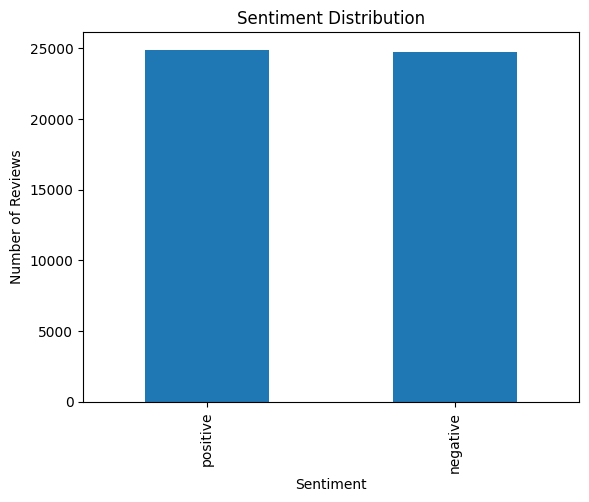

In [21]:


df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [22]:
df['review'] = df['review'].str.lower()

In [23]:
df['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fa

In [24]:
import re

In [25]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)

In [26]:
df['review'] = df['review'].apply(remove_html_tags)

In [27]:
df['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

In [28]:
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub('', text)

In [29]:
df['review'] = df['review'].apply(remove_url)

In [30]:
import string

In [31]:
import string

print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [32]:
def remove_punctuation(text):
    for char in string.punctuation:
        text = text.replace(char, '')
    return text

In [33]:
df['review'] = df['review'].apply(remove_punctuation)

In [34]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictur

In [35]:
import nltk

In [36]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vinod\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vinod\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [37]:
from nltk.tokenize import word_tokenize

In [38]:
def tokenize_text(text):
    return word_tokenize(text)

In [39]:
df['review'] = df['review'].apply(tokenize_text)

In [40]:
df['review'][0]

['one',
 'of',
 'the',
 'other',
 'reviewers',
 'has',
 'mentioned',
 'that',
 'after',
 'watching',
 'just',
 '1',
 'oz',
 'episode',
 'youll',
 'be',
 'hooked',
 'they',
 'are',
 'right',
 'as',
 'this',
 'is',
 'exactly',
 'what',
 'happened',
 'with',
 'methe',
 'first',
 'thing',
 'that',
 'struck',
 'me',
 'about',
 'oz',
 'was',
 'its',
 'brutality',
 'and',
 'unflinching',
 'scenes',
 'of',
 'violence',
 'which',
 'set',
 'in',
 'right',
 'from',
 'the',
 'word',
 'go',
 'trust',
 'me',
 'this',
 'is',
 'not',
 'a',
 'show',
 'for',
 'the',
 'faint',
 'hearted',
 'or',
 'timid',
 'this',
 'show',
 'pulls',
 'no',
 'punches',
 'with',
 'regards',
 'to',
 'drugs',
 'sex',
 'or',
 'violence',
 'its',
 'is',
 'hardcore',
 'in',
 'the',
 'classic',
 'use',
 'of',
 'the',
 'wordit',
 'is',
 'called',
 'oz',
 'as',
 'that',
 'is',
 'the',
 'nickname',
 'given',
 'to',
 'the',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'it',
 'focuses',
 'mainly',
 'on',
 'emerald',

In [41]:
from nltk.corpus import stopwords

In [42]:
stop_words = set(stopwords.words('english'))

In [43]:
print(list(stop_words)[:20])

['once', 'under', 'an', 'from', 'by', 'over', 'further', 'that', 'her', "they'd", 'through', 'being', "couldn't", 'their', 'which', 'd', 'against', 'are', 'isn', "you're"]


In [44]:
def remove_stopwords(tokens):
    filtered_words = []

    for word in tokens:
        if word not in stop_words:
            filtered_words.append(word)

    return filtered_words

In [45]:
df['review'] = df['review'].apply(remove_stopwords)

In [46]:
df['review'][0]

['one',
 'reviewers',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'youll',
 'hooked',
 'right',
 'exactly',
 'happened',
 'methe',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'wordit',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'manyaryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'moreso',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'awayi',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'f

In [47]:
from nltk.stem import PorterStemmer

In [48]:
ps = PorterStemmer()

In [49]:
print(ps.stem("playing"))
print(ps.stem("played"))
print(ps.stem("plays"))
print(ps.stem("beautiful"))

play
play
play
beauti


In [50]:
def stem_words(tokens):
    stemmed_words = []

    for word in tokens:
        stemmed_words.append(ps.stem(word))

    return stemmed_words

In [51]:
df['review'] = df['review'].apply(stem_words)

In [52]:
df['review'][0]

['one',
 'review',
 'mention',
 'watch',
 '1',
 'oz',
 'episod',
 'youll',
 'hook',
 'right',
 'exactli',
 'happen',
 'meth',
 'first',
 'thing',
 'struck',
 'oz',
 'brutal',
 'unflinch',
 'scene',
 'violenc',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'heart',
 'timid',
 'show',
 'pull',
 'punch',
 'regard',
 'drug',
 'sex',
 'violenc',
 'hardcor',
 'classic',
 'use',
 'wordit',
 'call',
 'oz',
 'nicknam',
 'given',
 'oswald',
 'maximum',
 'secur',
 'state',
 'penitentari',
 'focus',
 'mainli',
 'emerald',
 'citi',
 'experiment',
 'section',
 'prison',
 'cell',
 'glass',
 'front',
 'face',
 'inward',
 'privaci',
 'high',
 'agenda',
 'em',
 'citi',
 'home',
 'manyaryan',
 'muslim',
 'gangsta',
 'latino',
 'christian',
 'italian',
 'irish',
 'moreso',
 'scuffl',
 'death',
 'stare',
 'dodgi',
 'deal',
 'shadi',
 'agreement',
 'never',
 'far',
 'awayi',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'fact',
 'goe',
 'show',
 'wouldnt',
 'dare',
 'forget',
 'p

In [53]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vinod\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\vinod\AppData\Roaming\nltk_data...


True

In [54]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [55]:
print(lemmatizer.lemmatize("cars"))
print(lemmatizer.lemmatize("studies"))
print(lemmatizer.lemmatize("running"))

car
study
running


In [56]:
def lemmatize_words(tokens):
    lemmatized_words = []

    for word in tokens:
        lemmatized_words.append(lemmatizer.lemmatize(word))

    return lemmatized_words

In [57]:
df['review'] = df['review'].apply(lemmatize_words)

In [58]:
from sklearn.feature_extraction.text import CountVectorizer

In [59]:
df['review'] = df['review'].apply(lambda words: " ".join(words))

In [60]:
cv = CountVectorizer(max_features=5000)

In [61]:
X = cv.fit_transform(df['review'])

In [62]:
X.shape

(49582, 5000)

In [63]:
y = df['sentiment']

In [64]:
y.head()

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39665, 5000)
(9917, 5000)
(39665,)
(9917,)


In [68]:
from sklearn.naive_bayes import MultinomialNB

In [69]:
model = MultinomialNB()

In [70]:
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [71]:
y_pred = model.predict(X_test)

In [72]:
print(y_pred[:10])

['negative' 'positive' 'positive' 'negative' 'positive' 'positive'
 'negative' 'positive' 'negative' 'negative']


In [73]:
from sklearn.metrics import accuracy_score

In [74]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8396692548149642


In [75]:
from sklearn.metrics import confusion_matrix, classification_report

In [76]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4175  764]
 [ 826 4152]]


In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.83      0.85      0.84      4939
    positive       0.84      0.83      0.84      4978

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



In [78]:


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,negative,negative
1,positive,positive
2,negative,positive
3,negative,negative
4,positive,positive
5,positive,positive
6,negative,negative
7,negative,positive
8,negative,negative
9,positive,negative


In [79]:
import pickle

In [80]:
with open("../models/sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [81]:
with open("../models/vectorizer.pkl", "wb") as file:
    pickle.dump(cv, file)

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [83]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [85]:
type(X)

scipy.sparse._csr.csr_matrix

In [86]:
X_tfidf = tfidf.fit_transform(df['review'])

In [87]:
X_tfidf.shape

(49582, 5000)

In [95]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [96]:
from sklearn.linear_model import LogisticRegression

In [97]:
lr_model = LogisticRegression(max_iter=1000)

In [98]:
X_train_tfidf.shape

(39665, 5000)

In [99]:
X_test_tfidf.shape

(9917, 5000)

In [100]:
lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [101]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [102]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8854492285973581


In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4939
    positive       0.87      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



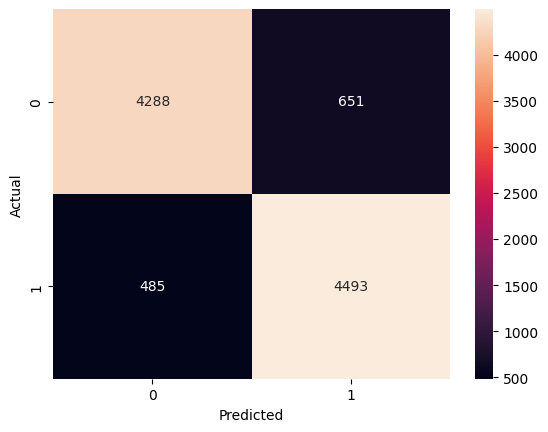

In [104]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [105]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_lr
    ]
})

comparison

,Model,Accuracy
0,Naive Bayes,0.839669
1,Logistic Regression,0.885449


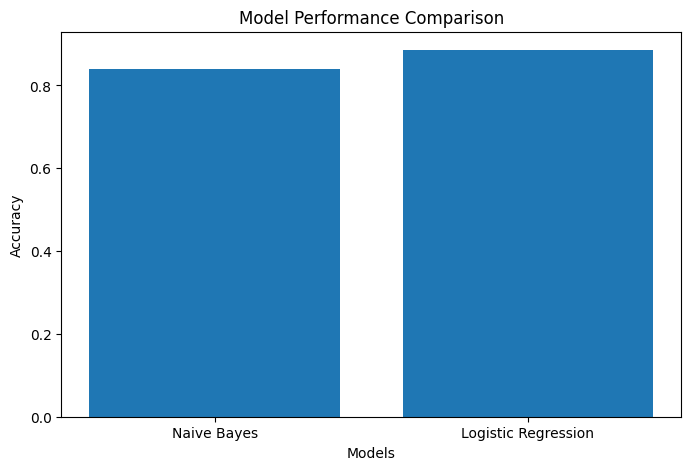

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Model Performance Comparison")

plt.show()

In [107]:
if accuracy_lr > accuracy:
    best_model = lr_model
    print("Logistic Regression selected")
else:
    best_model = model
    print("Naive Bayes selected")

Logistic Regression selected


In [108]:
comparison


,Model,Accuracy
0,Naive Bayes,0.839669
1,Logistic Regression,0.885449


In [109]:
with open("../models/sentiment_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

In [110]:
with open("../models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)